### IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap


### LOAD DATASET

In [7]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")
print(X.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


### NORMALIZE THE FEATURE

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### SPLIT INTO TRAIN AND TEST SET

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

### FIT KNN AND ELEVUATE DIFFERENT VALUES OF K

In [17]:
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"K={k}: Accuracy = {acc:.2f}")


K=1: Accuracy = 0.98
K=2: Accuracy = 0.98
K=3: Accuracy = 1.00
K=4: Accuracy = 0.98
K=5: Accuracy = 1.00
K=6: Accuracy = 1.00
K=7: Accuracy = 1.00
K=8: Accuracy = 1.00
K=9: Accuracy = 1.00
K=10: Accuracy = 1.00


###  Confusion Matrix for best K (e.g., K=3)

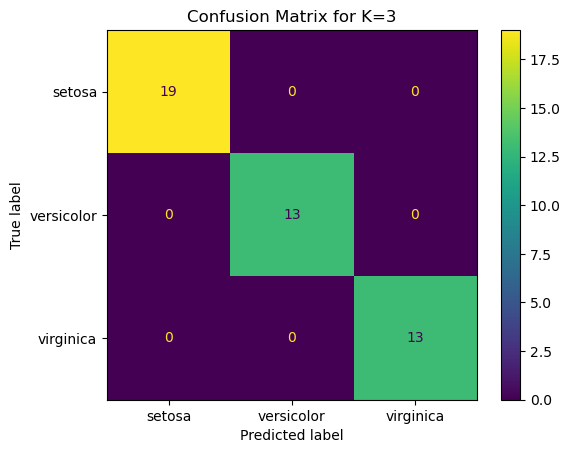

In [20]:
best_k = 3
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title(f"Confusion Matrix for K={best_k}")
plt.show()

### Visualize decision boundary (using only 2 features for 2D plot)

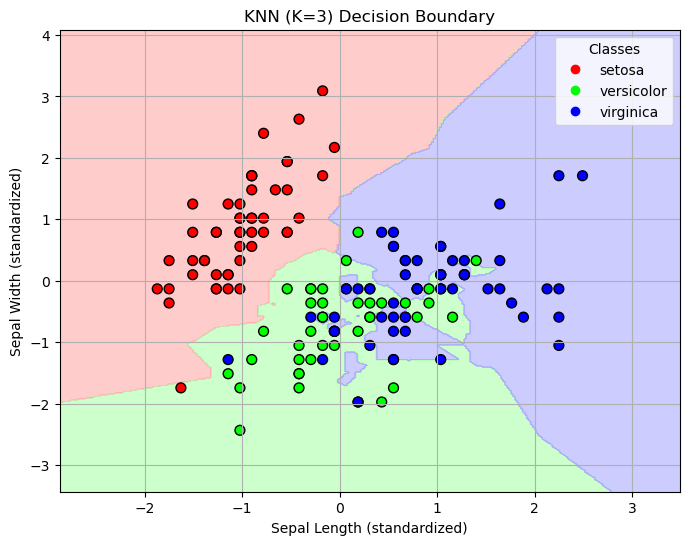

In [27]:
from matplotlib.colors import ListedColormap

# Use only the first two features for 2D visualization
X_vis = X.iloc[:, :2].values
y_vis = y.values

# Scale features
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Split into training/testing sets
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis_scaled, y_vis, test_size=0.3, random_state=42
)

# Train KNN classifier
knn_vis = KNeighborsClassifier(n_neighbors=3)
knn_vis.fit(X_train_vis, y_train_vis)

# Create mesh grid for decision boundary
h = 0.02
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
scatter = plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=50)

plt.xlabel("Sepal Length (standardized)")
plt.ylabel("Sepal Width (standardized)")
plt.title("KNN (K=3) Decision Boundary")

# Add legend safely using built-in handler
legend_labels = iris.target_names
legend_elements, _ = scatter.legend_elements()
plt.legend(legend_elements, legend_labels, title="Classes")

plt.grid(True)
plt.show()
